# Example of calculating shape parameter for 2015-04-17

In [319]:
# Import the libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import time
from datetime import datetime
import numpy as np
import pickle
import matplotlib.dates as mdates

## Load and read the insitu, time filtering files

In [594]:
# Read the insitu file
dir_insitu = '/Users/quocanh1306/Downloads/37.0/mvn_kp_insitu_20150417_v22_r01.tab'
df = pd.read_csv(dir_insitu, sep ='\t')
df.head()

,#
0,# MAVEN In Situ Key Parameters (cadence: 4 sec...
1,"# Maintained by Patrick Dunn, pdunn@ssl.berk..."
2,"# Generated on Fri Feb 21 07:19:37 2025, Pac..."
3,# Version number _v22 ...
4,# Revision number _r01 ...


In [235]:
# Open time ranges file
dir_timeranges = '/content/drive/MyDrive/MAVEN PROJECT /2 - Codes/30-05/time_ranges_17_4_2015_to_17_4_2015.pkl'
with open(dir_timeranges, "rb") as f:
    loaded_data = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MAVEN PROJECT /2 - Codes/30-05/time_ranges_17_4_2015_to_17_4_2015.pkl'

In [35]:
time_ranges = loaded_data["time_ranges"]

In [595]:
# Data cleaning for insitu
df = df.iloc[351:].reset_index(drop=True)
df = df.iloc[:, 0].str.split(r'\s+', expand=True)
df.iloc[:,0] = pd.to_datetime(df.iloc[:,0])

In [596]:
# Time filtering
start_date = pd.Timestamp('2015-04-17 05:16:52')
end_date = pd.Timestamp('2015-04-17 06:15:59')
df = df[(df.iloc[:,0] >= start_date) & (df.iloc[:,0] <= end_date)]

print(df)

                      0         1         2         3         4         5    \
2545  2015-04-17 05:16:56  1.66E+00  7.26E-01  8.71E+00  2.27E+04  9.69E+03   
2546  2015-04-17 05:17:04       NaN       NaN       NaN  5.83E+03  1.75E+03   
2547  2015-04-17 05:17:12  2.15E+00  5.23E-01  1.13E+01  5.83E+03  1.75E+03   
2548  2015-04-17 05:17:20       NaN       NaN       NaN  2.40E+04  9.00E+03   
2549  2015-04-17 05:17:28  2.28E+00  7.74E-01  1.74E+01  2.40E+04  9.00E+03   
...                   ...       ...       ...       ...       ...       ...   
3158  2015-04-17 06:15:20       NaN       NaN       NaN       NaN       NaN   
3159  2015-04-17 06:15:28       NaN       NaN       NaN       NaN       NaN   
3160  2015-04-17 06:15:36  1.76E+00  9.59E-01  9.05E+00       NaN       NaN   
3161  2015-04-17 06:15:44       NaN       NaN       NaN       NaN       NaN   
3162  2015-04-17 06:15:52       NaN       NaN       NaN       NaN       NaN   

           6    7    8    9    ...         225     

In [240]:
# Numeric conversion and filtering (keep NaNs)
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df[(df.iloc[:,7]) > -16].reset_index(drop=True)

In [241]:
# Prepare 8s data (keep all rows including NaNs)
df_8s = pd.DataFrame({
    'epoch': pd.to_datetime(df.iloc[:,0]),
    'phi_sc': df.iloc[:,7]  # This includes NaNs
})

In [254]:
print(df)

                      0         1         2         3         4         5    \
2545  2015-04-17 05:16:56  1.66E+00  7.26E-01  8.71E+00  2.27E+04  9.69E+03   
2546  2015-04-17 05:17:04       NaN       NaN       NaN  5.83E+03  1.75E+03   
2547  2015-04-17 05:17:12  2.15E+00  5.23E-01  1.13E+01  5.83E+03  1.75E+03   
2548  2015-04-17 05:17:20       NaN       NaN       NaN  2.40E+04  9.00E+03   
2549  2015-04-17 05:17:28  2.28E+00  7.74E-01  1.74E+01  2.40E+04  9.00E+03   
...                   ...       ...       ...       ...       ...       ...   
3158  2015-04-17 06:15:20       NaN       NaN       NaN       NaN       NaN   
3159  2015-04-17 06:15:28       NaN       NaN       NaN       NaN       NaN   
3160  2015-04-17 06:15:36  1.76E+00  9.59E-01  9.05E+00       NaN       NaN   
3161  2015-04-17 06:15:44       NaN       NaN       NaN       NaN       NaN   
3162  2015-04-17 06:15:52       NaN       NaN       NaN       NaN       NaN   

           6    7    8    9    ...         225     

In [255]:
data = df
out_df_new = pd.DataFrame({
                "datetime": np.repeat(np.array(data[0]), 16*64),
                "altitude": np.repeat(np.array(data[196]), 16*64),
                "SZA": np.repeat(np.array(data[194]), 16*64), 
                "B_x": np.repeat(np.array(data[133]), 16*64), 
                "B_y": np.repeat(np.array(data[135]), 16*64), 
                "B_z": np.repeat(np.array(data[137]), 16*64), 
                "GLON": np.repeat(np.array(data[192]), 16*64), 
                "GLAT": np.repeat(np.array(data[193]), 16*64), 
                "flux_parallel": np.repeat(np.array(data[30]), 16*64), 
                "flux_antiparallel": np.repeat(np.array(data[36]), 16*64), 
                "phi_sc": np.repeat(np.array(data[7]), 16*64)
            })

print(out_df_new)

                  datetime altitude    SZA        B_x        B_y        B_z  \
0      2015-04-17 05:16:56  2477.21  93.21   5.71E+00   1.24E+01   1.34E+00   
1      2015-04-17 05:16:56  2477.21  93.21   5.71E+00   1.24E+01   1.34E+00   
2      2015-04-17 05:16:56  2477.21  93.21   5.71E+00   1.24E+01   1.34E+00   
3      2015-04-17 05:16:56  2477.21  93.21   5.71E+00   1.24E+01   1.34E+00   
4      2015-04-17 05:16:56  2477.21  93.21   5.71E+00   1.24E+01   1.34E+00   
...                    ...      ...    ...        ...        ...        ...   
632827 2015-04-17 06:15:52  1145.27  83.78  -1.22E+01  -6.61E+00  -1.01E+01   
632828 2015-04-17 06:15:52  1145.27  83.78  -1.22E+01  -6.61E+00  -1.01E+01   
632829 2015-04-17 06:15:52  1145.27  83.78  -1.22E+01  -6.61E+00  -1.01E+01   
632830 2015-04-17 06:15:52  1145.27  83.78  -1.22E+01  -6.61E+00  -1.01E+01   
632831 2015-04-17 06:15:52  1145.27  83.78  -1.22E+01  -6.61E+00  -1.01E+01   

          GLON    GLAT flux_parallel flux_antiparal

In [ ]:
# Set the level 




In [231]:
# Preparing to merge
out_df = pd.DataFrame({
                "datetime": data[0],
                "altitude": data[196],
                "SZA": data[194],
                "B_x": data[133],
                "B_y": data[135],
                "B_z": data[137],
                "GLON": data[192],
                "GLAT": data[193],
                "flux_parallel": data[30],
                "flux_antiparallel": data[36],
                "phi_sc": data[7]
            })

print(out_df)

                 datetime altitude    SZA        B_x        B_y        B_z  \
2546  2015-04-17 05:17:04  2466.92  93.01   4.23E+00   1.31E+01   1.73E+00   
2547  2015-04-17 05:17:12  2456.62  92.81   4.80E+00   1.25E+01   1.53E+00   
2548  2015-04-17 05:17:20  2446.30  92.61   5.16E+00   1.30E+01   1.26E+00   
2549  2015-04-17 05:17:28  2435.98  92.41   5.38E+00   1.35E+01   1.25E+00   
2550  2015-04-17 05:17:36  2425.65  92.21   6.28E+00   1.34E+01   1.16E+00   
...                   ...      ...    ...        ...        ...        ...   
3158  2015-04-17 06:15:20  1104.51  82.43  -1.16E+01  -6.66E+00  -1.02E+01   
3159  2015-04-17 06:15:28  1114.67  82.77  -1.15E+01  -6.91E+00  -1.03E+01   
3160  2015-04-17 06:15:36  1124.85  83.11  -1.27E+01  -6.23E+00  -1.06E+01   
3161  2015-04-17 06:15:44  1135.05  83.44  -1.11E+01  -6.61E+00  -9.77E+00   
3162  2015-04-17 06:15:52  1145.27  83.78  -1.22E+01  -6.61E+00  -1.01E+01   

        GLON    GLAT flux_parallel flux_antiparallel phi_sc  
2

In [232]:
# Convert datetime
out_df["datetime"] = pd.to_datetime(out_df["datetime"])

# Convert all remaining columns to numeric
for col in out_df.columns:
    if col != "datetime":
        out_df[col] = pd.to_numeric(out_df[col], errors="coerce")

print(out_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 617 entries, 2546 to 3162
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   datetime           617 non-null    datetime64[ns]
 1   altitude           617 non-null    float64       
 2   SZA                617 non-null    float64       
 3   B_x                617 non-null    float64       
 4   B_y                617 non-null    float64       
 5   B_z                617 non-null    float64       
 6   GLON               617 non-null    float64       
 7   GLAT               617 non-null    float64       
 8   flux_parallel      555 non-null    float64       
 9   flux_antiparallel  527 non-null    float64       
 10  phi_sc             366 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 57.8 KB
None


## Load and read the CDF file

In [14]:
pip install spacepy

In [16]:
# Import the libraries
import spacepy.pycdf as pycdf
from datetime import datetime as dt
import os

/Users/quocanh1306/Desktop/miniconda3/envs/qanh-env/lib/python3.10/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()


In [169]:
# Create empty lists to store data
b_azim = []
b_elev = []
binning = []
counts = []
d_pa = []
de_over_e = []
diff_en_fluxes = []
en_label = []
energy = []
epoch = []
g_engy = []
g_pa = []
geom_factor = []
num_dists = []
pa = []
pa_label = []
pindex = []
time_met = []
time_unix = []

In [170]:
# Path to saved PAD data
path_in = '/Users/quocanh1306/Downloads/'

# List of years and months data
years = ['2015']
months = ['04']

In [171]:
# Run this loop to read the files and necessary columns
for year in years:
 path_year = path_in #+ f'/{year}'
 for month in months:
    path = path_year #+ f'/{month}/'
    for filename in os.listdir(path):
      if filename.endswith('20150417_v05_r01.cdf'):
       print(filename)
       filepath = os.path.join(path, filename)
       readfile = pycdf.CDF(filepath)
       b_azim.append(readfile['b_azim'][:])
       b_elev.append(readfile['b_elev'][:])
       diff_en_fluxes.append(readfile['diff_en_fluxes'][:])
       pa.append(readfile['pa'][:])
       energy.append(readfile['energy'][:])
       epoch.append(readfile['epoch'][:])

mvn_swe_l2_svypad_20150417_v05_r01.cdf


In [172]:
# Optional: Run this to check the data in the columns
print(b_azim) #shape = (30870,1)
print(b_elev) #shape = (30870,1)
print(diff_en_fluxes) #shape = (30870, 16, 64)
print(energy) #shape = (64,1)
print(epoch) #shape = (30870,1)
print(pa) #shape = (30870, 16, 64)

[array([153.98436, 201.79686, 166.64061, ..., 308.67184, 311.48438,
       311.48438], dtype=float32)]
[array([-78.74999, -87.75   , -74.25   , ...,   2.25   ,  -2.25   ,
        -2.25   ], dtype=float32)]
[array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         7.33979440e+07, 1.42680784e+08, 1.42680784e+08],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         7.30496960e+07, 1.26747048e+08, 1.26747048e+08],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.33558776e+08, 2.36079344e+08, 2.36079344e+08],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         2.39728560e+08, 2.26277904e+08, 2.26277904e+08],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.26461888e+08, 1.24311760e+08, 1.24311760e+08],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.13424256e+08, 1.70821424e+08, 1.70821424e+08]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, .

In [173]:
# Convert other columns into numpy array type
b_azim = np.squeeze(np.array(b_azim))
b_elev = np.squeeze(np.array(b_elev))
energy = np.squeeze(np.array(energy))
epoch = np.squeeze(np.array(epoch))
diff_en_fluxes = np.squeeze(np.array(diff_en_fluxes))
pa = np.squeeze(np.array(pa))

In [178]:
# Create a multi-index dataframe
names = ['epoch', 'pa bin', 'energy']
index = pd.MultiIndex.from_product([range(s)for s in diff_en_fluxes.shape], names = names)

# Replace the integer levels with actual values
index = index.set_levels([
    epoch,
    index.levels[1],                # Keep pa bin level as is
    energy
])

df_pad = pd.DataFrame({'def': diff_en_fluxes.flatten(),
                   'pa values': pa.flatten(),
                   'b_azim': np.repeat(b_azim, 16 * 64),
                   'b_elev': np.repeat(b_elev, 16 * 64)},
                   index=index)

# Reset the indices
df_pad = df_pad.reset_index()
df_pad = df_pad.set_index(['epoch', 'b_azim', 'b_elev', 'pa bin', 'energy'])
print(df_pad)

                                                                             def  \
epoch                      b_azim     b_elev     pa bin energy                     
2015-04-17 00:00:01.722221 153.984360 -78.749992 0      4627.500000          0.0   
                                                        4118.505859          0.0   
                                                        3665.497559          0.0   
                                                        3262.317139          0.0   
                                                        2903.483887          0.0   
...                                                                          ...   
2015-04-17 23:59:59.032771 311.484375 -2.250000  15     4.781325     342076608.0   
                                                        4.255411     272957952.0   
                                                        3.787344     272957952.0   
                                                        3.370761     2287821

In [179]:
df_pad = df_pad[(df_pad.index.get_level_values('epoch') >= start_date) &
                (df_pad.index.get_level_values('epoch') <= end_date)]

In [228]:
print(df_pad)

                                                                             def  \
epoch                      b_azim     b_elev     pa bin energy                     
2015-04-17 05:17:01.572786 124.453117 -51.749996 0      4627.500000          0.0   
                                                        4118.505859          0.0   
                                                        3665.497559          0.0   
                                                        3262.317139          0.0   
                                                        2903.483887          0.0   
...                                                                          ...   
2015-04-17 06:15:57.544014 26.015623   69.750000 15     4.781325     150367568.0   
                                                        4.255411     267149184.0   
                                                        3.787344     267149184.0   
                                                        3.370761     2740431

In [371]:
# First, ensure both dataframes have datetime columns
df_env_new = out_df_new.copy()
# Assuming 'epoch' is the name of the datetime index level in df_pad
# STEP 1 — reset df_pad index
df_pad_reset = df_pad.reset_index()

# STEP 2 — prepare df_env so it has an 'epoch' column
# If df_env already has epoch values, rename:
# df_env = df_env.rename(columns={'datetime':'epoch'})

# Otherwise convert datetime → numeric epoch
df_env_new['epoch'] = pd.to_datetime(df_env_new['datetime'])

# STEP 3 — also convert df_pad epoch (if needed)
df_pad_reset['epoch'] = pd.to_datetime(df_pad_reset['epoch'])

# STEP 4 — perform merge
df_merged = pd.merge_asof(
    df_pad_reset,
    df_env_new,
    on='epoch',
    direction='nearest',
    tolerance=pd.Timedelta('6s')   # choose tolerance you want
)

# STEP 5 — set final index again if you want
df_merged = df_merged.set_index(
    ['epoch', 'b_azim', 'b_elev', 'pa bin', 'altitude','SZA', 'B_x', 'B_y', 'B_z', 'GLON', 'GLAT', 'flux_parallel', 'flux_antiparallel', 'phi_sc', 'energy']
)

print(df_merged)


                                                                                                                                                                               def  \
epoch                      b_azim     b_elev     pa bin altitude SZA   B_x       B_y       B_z       GLON   GLAT   flux_parallel flux_antiparallel phi_sc energy                     
2015-04-17 05:17:01.572786 124.453117 -51.749996 0      2466.92  93.01 4.23E+00  1.31E+01  1.73E+00  87.89  -67.35 2.86E+05      1.68E+05          NaN    4627.500000          0.0   
                                                                                                                                                          4118.505859          0.0   
                                                                                                                                                          3665.497559          0.0   
                                                                                          

In [372]:
# Create columns of log10 of F and E 

df_merged['log_F'] = np.where(
    (df_merged['def'] > 0) & (~np.isinf(df_merged['def'])) & (~np.isnan(df_merged['def'])),
    np.log10(df_merged['def']),
    np.nan  # Replace invalid values with NaN
)

df_merged['log_E'] = np.where(
    (df_merged.index.get_level_values('energy') > 0) & (~np.isinf(df_merged.index.get_level_values('energy'))) & (~np.isnan(df_merged.index.get_level_values('energy'))),
    np.log10(df_merged.index.get_level_values('energy')),
    np.nan  # Replace invalid values with NaN
)

print(df_merged)

                                                                                                                                                                               def  \
epoch                      b_azim     b_elev     pa bin altitude SZA   B_x       B_y       B_z       GLON   GLAT   flux_parallel flux_antiparallel phi_sc energy                     
2015-04-17 05:17:01.572786 124.453117 -51.749996 0      2466.92  93.01 4.23E+00  1.31E+01  1.73E+00  87.89  -67.35 2.86E+05      1.68E+05          NaN    4627.500000          0.0   
                                                                                                                                                          4118.505859          0.0   
                                                                                                                                                          3665.497559          0.0   
                                                                                          

/Users/quocanh1306/Desktop/miniconda3/envs/qanh-env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [373]:
# Convert all remaining columns to numeric
for col in df_merged.columns:
    if col != "datetime":
        df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

print(df_merged.info())

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1811456 entries, (Timestamp('2015-04-17 05:17:01.572786'), 124.45312, -51.749996, 0, '2466.92', '93.01', '4.23E+00', '1.31E+01', '1.73E+00', '87.89', '-67.35', '2.86E+05', '1.68E+05', 'NaN', 4627.5) to (Timestamp('2015-04-17 06:15:57.544014'), 26.015623, 69.75, 15, '1145.27', '83.78', '-1.22E+01', '-6.61E+00', '-1.01E+01', '248.30', '65.02', '4.08E+05', '2.08E+05', 'NaN', 3.0)
Data columns (total 5 columns):
 #   Column     Dtype         
---  ------     -----         
 0   def        float32       
 1   pa values  float32       
 2   datetime   datetime64[ns]
 3   log_F      float32       
 4   log_E      float32       
dtypes: datetime64[ns](1), float32(4)
memory usage: 88.4+ MB
None


In [597]:
# Extract Epoch (X-axis)
epochs = df_merged.index.get_level_values('epoch')
b_azims = df_merged.index.get_level_values('b_azim')
b_elevs = df_merged.index.get_level_values('b_elev')

# Extract Y-axis data for Panel 1 & 2
altitude = df_merged.index.get_level_values('altitude').astype(float)
sza = df_merged.index.get_level_values('SZA').astype(float)

# Extract B components for Panel 4
bx = df_merged.index.get_level_values('B_x').astype(float)
by = df_merged.index.get_level_values('B_y').astype(float)
bz = df_merged.index.get_level_values('B_z').astype(float)

# Calculate Magnitude |B| for Panel 3
# Formula: sqrt(Bx^2 + By^2 + Bz^2)
# We ensure they are numpy arrays, floats for calculation
b_magnitude = np.sqrt(np.array(bx)**2 +
                      np.array(by)**2 +
                      np.array(bz)**2)

print(b_magnitude)

[13.87428557 13.87428557 13.87428557 ... 17.16222888 17.16222888
 17.16222888]


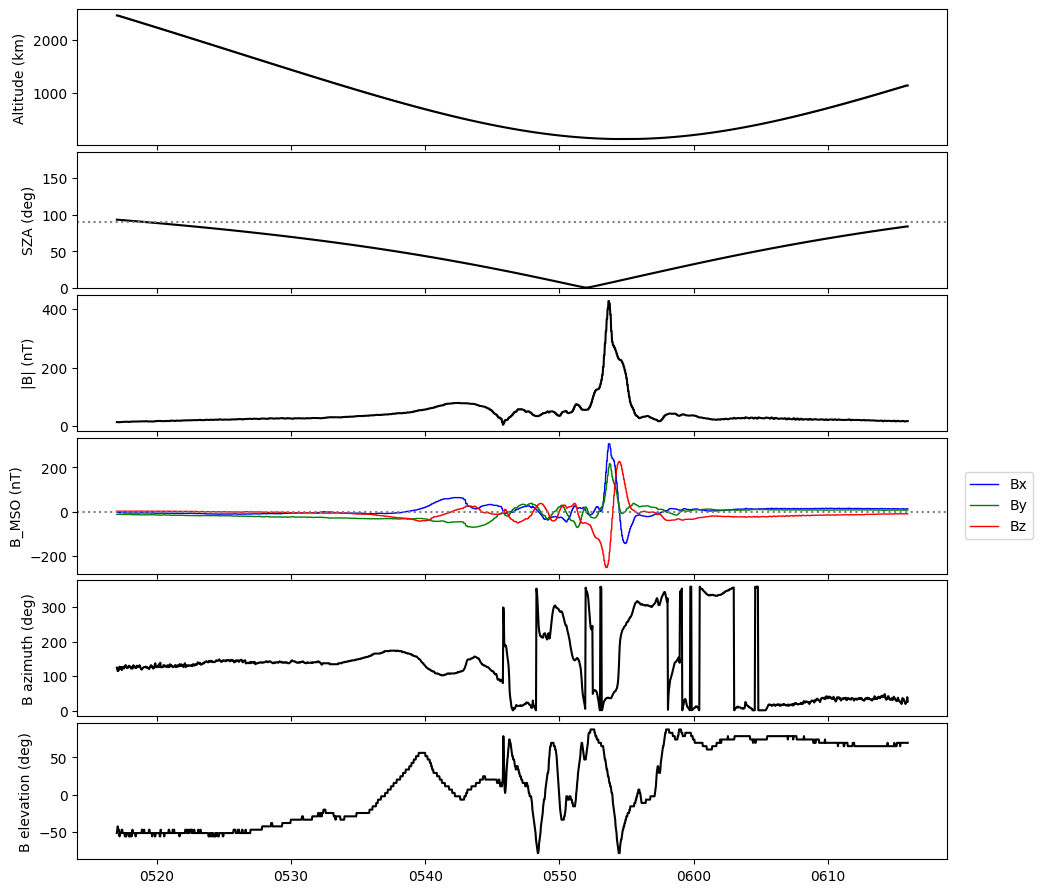

In [599]:
# 3. Plotting
# ==========================================
# Create 4 subplots vertically with a shared X-axis
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 10), sharex=True)

# Unpack axes for easier reference
ax_alt, ax_sza, ax_bmag, ax_bcomp, ax_bazim, ax_belev = axes

# --- Panel 1: Altitude ---
# Note: The reference image has colored regions (Sheath/Pileup).
# Without that region data, we plot a single line.
ax_alt.plot(epochs, altitude, color='black', linewidth=1.5)
ax_alt.set_ylabel('Altitude (km)')
# Optional: Invert Y axis if altitude implies depth, but image shows normal scale
# ax_alt.invert_yaxis()

# --- Panel 2: SZA ---
ax_sza.plot(epochs, sza, color='black')
ax_sza.set_ylabel('SZA (deg)')
# Add the 90-degree terminator line seen in the image
ax_sza.axhline(90, color='gray', linestyle=':')
ax_sza.set_ylim(0, 185) # Approx limits from image

# --- Panel 3: Total Magnetic Field (|B|) ---
ax_bmag.plot(epochs, b_magnitude, color='black')
ax_bmag.set_ylabel('|B| (nT)')
#ax_bmag.set_ylim(bottom=0) # Magnitude can't be negative

# --- Panel 4: Magnetic Field Components (B_MSO) ---
# Using standard colors from the image: Bx=blue, By=green, Bz=red
ax_bcomp.plot(epochs, -1*bx, color='blue', label='Bx', linewidth=1)
ax_bcomp.plot(epochs, -1*by, color='green', label='By', linewidth=1)
ax_bcomp.plot(epochs, 1*bz, color='red', label='Bz', linewidth=1)
ax_bcomp.set_ylabel('B_MSO (nT)')
ax_bcomp.axhline(0, color='gray', linestyle=':') # Zero line
# Place legend outside to the right, similar to the image's style
ax_bcomp.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

# --- Panel 5: B azim ---
# Note: The reference image has colored regions (Sheath/Pileup).
# Without that region data, we plot a single line.
ax_bazim.plot(epochs, b_azims, color='black', linewidth=1.5)
ax_bazim.set_ylabel('B azimuth (deg)')

# --- Panel 5: B azim ---
# Note: The reference image has colored regions (Sheath/Pileup).
# Without that region data, we plot a single line.
ax_belev.plot(epochs, b_elevs, color='black', linewidth=1.5)
ax_belev.set_ylabel('B elevation (deg)')


# ==========================================
# 4. X-Axis Formatting (hhmm)
# ==========================================
# Define the specific date formatter
date_fmt = mdates.DateFormatter('%H%M')

# Apply formatter to the bottom axis (which is shared by all)
ax_bcomp.xaxis.set_major_formatter(date_fmt)

# Optional: Set ticks to specific intervals (e.g., every 10 minutes)
# ax_bcomp.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))

# Set the X-label combining format and date, similar to image bottom left
# Assuming all data is from the same day, take the date from the first entry
date_str = epochs[0].strftime('%Y %b %d')
ax_bcomp.set_xlabel(f'hhmm\n{date_str}', fontsize=12, ha='left', x=0)

# Remove x-tick labels from top 3 plots to clean up borders
for ax in [ax_alt, ax_sza, ax_bmag]:
    plt.setp(ax.get_xticklabels(), visible=False)

# Fine-tune layout to reduce space between plots
plt.subplots_adjust(hspace=0.05, right=0.85, top=0.95, bottom=0.1)

plt.show()

In [376]:
# Update the analysis sections to use corrected energy:
df_a = df_merged[(df_merged['pa values'] >= 120) & (df_merged['pa values'] <= 180)].copy()
df_p = df_merged[(df_merged['pa values'] >= 0) & (df_merged['pa values'] <= 60)].copy()

In [469]:
# Extract data for the specific epoch
target_epoch = '2015-04-17 05:47:17'

# Retrieve the row(s)
epoch_data_a = df_a.loc[target_epoch]
epoch_data_p = df_p.loc[target_epoch]

print(epoch_data_a)

                                                                                                                                                                                def  \
epoch                      b_azim    b_elev    pa bin altitude SZA   B_x       B_y       B_z       GLON   GLAT   flux_parallel flux_antiparallel phi_sc    energy                     
2015-04-17 05:47:17.557986 14.765623 15.749999 6      296.67   18.61 -2.02E+01 -3.30E+01 -4.13E+01 208.51 -31.15 1.62E+05      1.31E+05          -1.30E+00 4627.500000          0.0   
                                                                                                                                                           4118.505859          0.0   
                                                                                                                                                           3665.497559          0.0   
                                                                                     

In [470]:
# 2. Extract Metadata for the Legend
# Since these are likely constant for the single timestamp, we take the first available value.
# For columns:
alt_val_a = epoch_data_a.index.get_level_values('altitude')[0]
sza_val_a = epoch_data_a.index.get_level_values('SZA')[0]

# For indices (using get_level_values):
# We access the values from the index of the sliced dataframe
b_azim_val_a = epoch_data_a.index.get_level_values('b_azim')[0]
b_elev_val_a = epoch_data_a.index.get_level_values('b_elev')[0]

print(alt_val_a)
print(sza_val_a)
print(b_azim_val_a)
print(b_elev_val_a)


296.67
18.61
14.765623
15.749999


In [471]:
alt_val_p = epoch_data_p.index.get_level_values('altitude')[0]
sza_val_p = epoch_data_a.index.get_level_values('SZA')[0]

# For indices (using get_level_values):
# We access the values from the index of the sliced dataframe
b_azim_val_p = epoch_data_p.index.get_level_values('b_azim')[0]
b_elev_val_p = epoch_data_p.index.get_level_values('b_elev')[0]

print(alt_val_p)
print(sza_val_p)
print(b_azim_val_p)
print(b_elev_val_p)

296.67
18.61
14.765623
15.749999


In [472]:
avg_def_a = epoch_data_a.groupby(level='energy')['def'].mean()
avg_def_p = epoch_data_p.groupby(level='energy')['def'].mean()

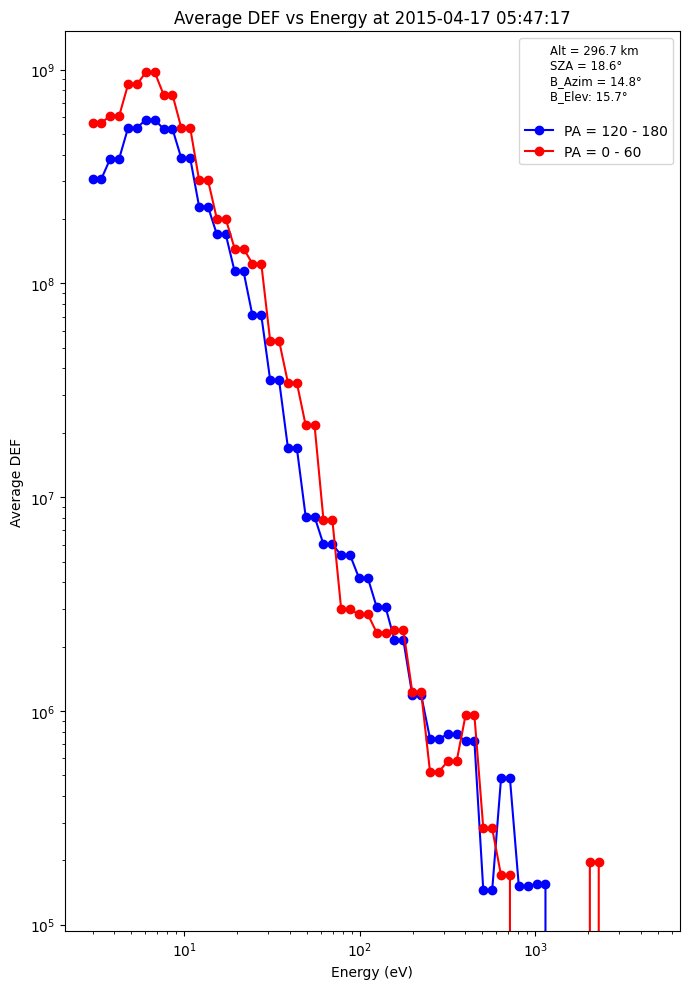

In [473]:
# 1. Setup the plot
plt.figure(figsize=(7, 10))

# 2. Plot the two lines
plt.plot(avg_def_a.index, avg_def_a.values, marker='o', linestyle='-', label='PA = 120 - 180', color='blue')
plt.plot(avg_def_p.index, avg_def_p.values, marker='o', linestyle='-', label='PA = 0 - 60', color='red')

# 3. Labeling the Axes
plt.xlabel('Energy (eV)')
plt.ylabel('Average DEF')
plt.title(f'Average DEF vs Energy at {target_epoch}')

# 4. Create the Metadata String (Converted to float to avoid ValueError)
# We use a raw string or newline characters to make it look neat
info_text = (f"Alt = {float(alt_val_a):.1f} km\n"
             f"SZA = {float(sza_val_a):.1f}°\n"
             f"B_Azim = {float(b_azim_val_a):.1f}°\n"
             f"B_Elev: {float(b_elev_val_a):.1f}°\n")

# 5. Set Scales and Grid
plt.xscale('log')
plt.yscale('log')

# 6. Create Legend with the Metadata as the Title
# 'title_fontsize' makes the metadata slightly distinct from the keys
plt.legend(loc='best', title=info_text, title_fontsize='small')

plt.tight_layout()
plt.show()

In [474]:
print(avg_def_a.index)
print(avg_def_a.values)

Index([               3.0, 3.3707613945007324,  3.787343978881836,
        4.255410671234131,  4.781324863433838,   5.37223482131958,
       6.0361738204956055,  6.782167434692383,  7.620355606079102,
          8.5621337890625,    9.6203031539917, 10.809247970581055,
       12.145132064819336, 13.646113395690918, 15.332597732543945,
       17.227508544921875,  19.35660743713379,  21.74883460998535,
       24.436710357666016, 27.456771850585938, 30.850074768066406,
        34.66274642944336, 38.946617126464844,  43.75991439819336,
         49.1680793762207,   55.2446174621582, 62.072139739990234,
        69.74345397949219,  78.36284637451172,   88.0474853515625,
        98.92902374267578,  111.1553726196289, 124.89274597167969,
         140.327880859375, 157.67059326171875, 177.15664672851562,
       199.05093383789062, 223.65106201171875, 251.29144287109375,
       282.34783935546875,  317.2424011230469,   356.449462890625,
       400.50201416015625,  449.9989013671875, 505.61297607421

In [464]:
# The function x_vals for flux, f_vals for energy 
def lagrangian_derivative(x_vals, f_vals, target_index):
    """
    Calculate the derivative at the target_index using three-point Lagrangian interpolation.

    Parameters:
        x_vals (list or numpy array): The x-coordinates of the points.
        f_vals (list or numpy array): The y-coordinates (function values) of the points.
        target_index (int): The index of the middle point (x2).

    Returns:
        float: The derivative at the target_index.
    """
    if target_index == 0 or target_index == len(x_vals) - 1:
        raise ValueError("Cannot calculate three-point derivative at the boundaries.")
    
    # Extract the three points: x1, x2, x3
    x1, x2, x3 = x_vals[target_index - 1], x_vals[target_index], x_vals[target_index + 1]
    f1, f2, f3 = f_vals[target_index - 1], f_vals[target_index], f_vals[target_index + 1]
    
    # Compute the derivative
    term1 = f1 * (2 * x2 - x3 - x2) / ((x1 - x2) * (x1 - x3))
    term2 = f2 * (2 * x2 - x1 - x3) / ((x2 - x1) * (x2 - x3))
    term3 = f3 * (2 * x2 - x1 - x2) / ((x3 - x1) * (x3 - x2))
    
    derivative = term1 + term2 + term3
    
    return derivative, f2

In [578]:
df_observed_a = []
energy_observed_a = []
epoch_a = df_a.index.get_level_values("epoch").unique()

In [577]:
targ_epoch = '2015-04-17 05:51:11'

epoch_a1 = np.array([targ_epoch])
print(epoch_a1)

['2015-04-17 05:51:11']


In [579]:
# Loop over each epoch
for epoch_val in epoch_a1:

    # extract data for this epoch
    df3a = df_a.loc[targ_epoch]
    avg_def_a = df3a.groupby(level='energy')['def'].mean()

    # find all template spectra inside this epoch
    unique_spec_template_a = df3a.index.get_level_values("pa bin").unique()

    # loop over all spectra
    for pa_bin in unique_spec_template_a:

        # extract data for this specific spectrum
        df3 = df3a[df3a.index.get_level_values("pa bin") == pa_bin].copy()

        # extract arrays (reverse as in your code)
        F = avg_def_a.values[::-1]
        E = df3.index.get_level_values("energy").to_numpy()
        F_log = np.log10(F)
        E_log = np.log10(E)

        print(len(F_log))
        print(len(E_log))

        # storage for this single spectrum
        df_array = []
        energy_array = []

        # compute Lagrangian derivative for each interior point
        for j in range(len(E_log) - 2):
            t = j + 1
            df_val, _ = lagrangian_derivative(E_log, F_log, t)
            
            # store
            energy_array.append(E[t])
            df_array.append(df_val * -1) #Multiply 0.051

        # append final arrays for this spectrum
        df_observed_a.append(df_array)
        energy_observed_a.append(energy_array)

64
64
64
64
64
64
64
64
64
64


/var/folders/fw/_vv3v5xx4237m2_lkjg3_0s00000gn/T/ipykernel_21837/3389367480.py:20: RuntimeWarning: divide by zero encountered in log10
  F_log = np.log10(F)
/var/folders/fw/_vv3v5xx4237m2_lkjg3_0s00000gn/T/ipykernel_21837/697614677.py:23: RuntimeWarning: invalid value encountered in scalar multiply
  term2 = f2 * (2 * x2 - x1 - x3) / ((x2 - x1) * (x2 - x3))
/var/folders/fw/_vv3v5xx4237m2_lkjg3_0s00000gn/T/ipykernel_21837/697614677.py:26: RuntimeWarning: invalid value encountered in scalar add
  derivative = term1 + term2 + term3


In [580]:
df_observed_a_0 = np.array(df_observed_a[0]).flatten()
energy_observed_a_0 = np.array(energy_observed_a[0]).flatten()

print(df_observed_a_0)
print(energy_observed_a_0)

[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         inf
        -inf         nan         nan         nan         nan         inf
 -2.3591616  -2.35915975 -0.0913785  -0.0913785   0.92552057  0.92552057
  4.83569671  4.83569671 -1.92648164 -1.92648164  3.59070474  3.59071214
 -1.53265589 -1.53265102  1.32987586  1.32987894  5.12962867  5.12962867
  5.72661349  5.72661349  1.88107722  1.88107843  2.79641473  2.79641473
  2.92243312  2.92243442  0.3120701   0.3120701   0.94820502  0.94820502
  2.63714248  2.63714385  3.08146608  3.08146608  2.03071701  2.03071793
  1.04830027  1.04829953 -1.36108593 -1.36108544 -2.83653551 -2.83653479
  0.14464336  0.14463925]
[4.11850586e+03 3.66549756e+03 3.26231714e+03 2.90348389e+03
 2.58412012e+03 2.29988403e+03 2.04691211e+03 1.82176538e+03
 1.62138330e+03 1.44304187e+03 1.28431689e+03 1.14305054e+03
 1.01732263e+03 9.05423889e+02 8.05833252e+02 7.17196960e+02


In [581]:
#Calculate shape parameter
df_observed_a_0_8020 = df_observed_a_0[34:46]*0.05

df_8020_template = [0.20805, 0.20805, 0.31019, 0.31019, 0.09985, 0.09985, 0.12199, 0.12199, 0.16288, 0.16288, 0.04065, 0.04065] 

shape_a = np.sum(np.array(abs(df_observed_a_0_8020 - df_8020_template)))

print(shape_a)

0.27544482109169893


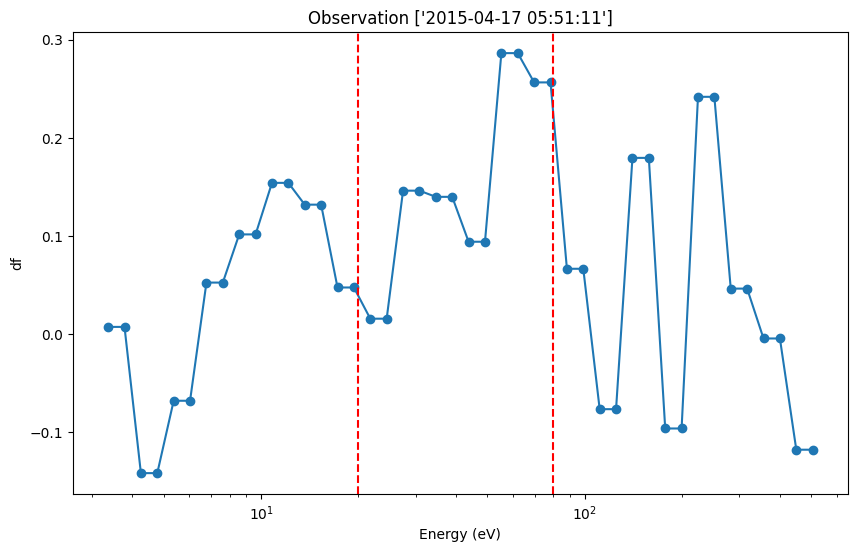

In [582]:
plt.figure(figsize=(10, 6))

# Plot your data
plt.plot(energy_observed_a_0, df_observed_a_0*0.05, marker='o', linestyle='-') 

# Set the title using an f-string to insert the epoch value.
# We use .strftime() to format the datetime object nicely in the title.
title_string = f"Observation {epoch_a1}"
plt.title(title_string)

plt.xlabel('Energy (eV)')
plt.ylabel('df')
plt.xscale('log') 

# Add the vertical lines (plt.axvline)
# Line 1: Energy = 20
plt.axvline(x=20, color='r', linestyle='--', linewidth=1.5, label='E = 20')
# Line 2: Energy = 80
plt.axvline(x=80, color='r', linestyle='--', linewidth=1.5, label='E = 80')

plt.show()

In [583]:
df_observed_p = []
energy_observed_p = []
epoch_p = df_p.index.get_level_values("epoch").unique()

In [584]:
# Loop over each epoch
for epoch_val in epoch_a1:

    # extract data for this epoch
    df3p = df_p.loc[targ_epoch]
    avg_def_p = df3p.groupby(level='energy')['def'].mean()

    # find all template spectra inside this epoch
    unique_spec_template_p = df3p.index.get_level_values("pa bin").unique()

    # loop over all spectra
    for pa_bin in unique_spec_template_p:

        # extract data for this specific spectrum
        df3_p = df3p[df3p.index.get_level_values("pa bin") == pa_bin].copy()

        # extract arrays (reverse as in your code)
        F_p = avg_def_p.values[::-1]
        E_p = df3p.index.get_level_values("energy").to_numpy()
        F_log_p = np.log10(F_p)
        E_log_p = np.log10(E_p)

        # storage for this single spectrum
        df_array_p = []
        energy_array_p = []

        # compute Lagrangian derivative for each interior point
        for j in range(len(F_log_p) - 2):
            t = j + 1
            df_val_p, _ = lagrangian_derivative(E_log_p, F_log_p, t)
            
            # store
            energy_array_p.append(E_p[t])
            df_array_p.append(df_val_p * -1) #Multiply 0.051

        # append final arrays for this spectrum
        df_observed_p.append(df_array_p)
        energy_observed_p.append(energy_array_p)

/var/folders/fw/_vv3v5xx4237m2_lkjg3_0s00000gn/T/ipykernel_21837/2184495342.py:20: RuntimeWarning: divide by zero encountered in log10
  F_log_p = np.log10(F_p)
/var/folders/fw/_vv3v5xx4237m2_lkjg3_0s00000gn/T/ipykernel_21837/697614677.py:23: RuntimeWarning: invalid value encountered in scalar multiply
  term2 = f2 * (2 * x2 - x1 - x3) / ((x2 - x1) * (x2 - x3))


In [585]:
df_observed_p_0 = np.array(df_observed_p[0]).flatten()
energy_observed_p_0 = np.array(energy_observed_p[0]).flatten()

print(df_observed_p_0)
print(energy_observed_p_0)

[        nan         nan         nan         nan         nan         nan
         nan         inf        -inf         nan         nan         nan
         nan         nan         nan         nan         nan         inf
  5.69863953  5.69864128 -0.03542825 -0.03542825 -3.19631107 -3.19631107
  4.78627619  4.78627619  3.0186092   3.0186092  -0.83503249 -0.83503543
  1.75559256  1.7555859   2.20767722  2.20768134  2.81370484  2.81370484
  6.61923573  6.61923573  1.73848374  1.73848495  2.0475737   2.0475737
  3.16741012  3.1674114   0.75292564  0.75292564  0.77656646  0.77656646
  2.13019998  2.13020133  3.17339107  3.17339107  1.98892864  1.98892953
  1.25984284  1.25984211 -0.95767477 -0.95767453 -2.81697463 -2.81697391
 -0.30839536 -0.30839957]
[4.11850586e+03 3.66549756e+03 3.26231714e+03 2.90348389e+03
 2.58412012e+03 2.29988403e+03 2.04691211e+03 1.82176538e+03
 1.62138330e+03 1.44304187e+03 1.28431689e+03 1.14305054e+03
 1.01732263e+03 9.05423889e+02 8.05833252e+02 7.17196960e+02
 

In [586]:
#Calculate shape parameter
df_observed_p_0_8020 = df_observed_p_0[34:46]*0.05

shape_p = np.sum(np.array(abs(df_observed_p_0_8020 - df_8020_template)))

print(shape_p)

0.25637364444647964


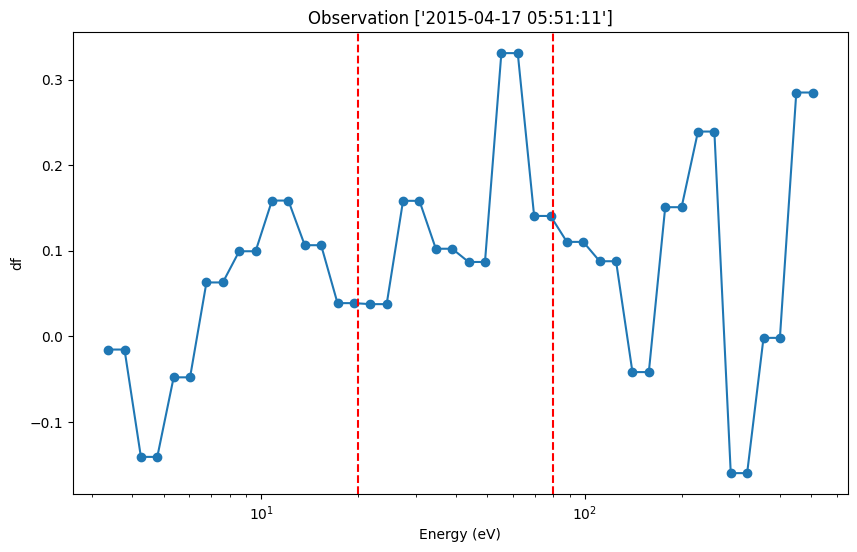

In [587]:
plt.figure(figsize=(10, 6))

# Plot your data
plt.plot(energy_observed_p_0, df_observed_p_0 * 0.05, marker='o', linestyle='-') 

# Set the title using an f-string to insert the epoch value.
# We use .strftime() to format the datetime object nicely in the title.
title_string = f"Observation {epoch_a1}"
plt.title(title_string)

plt.xlabel('Energy (eV)')
plt.ylabel('df')
plt.xscale('log') 

# Add the vertical lines (plt.axvline)
# Line 1: Energy = 20
plt.axvline(x=20, color='r', linestyle='--', linewidth=1.5, label='E = 20')
# Line 2: Energy = 80
plt.axvline(x=80, color='r', linestyle='--', linewidth=1.5, label='E = 80')

plt.show()

In [608]:
dir_insitu = '/Users/quocanh1306/Downloads/Insitu_All_20140318_to_20241114.csv'
df_insitu_all = pd.read_csv(dir_insitu)
df_insitu_all.head()

,datetime,altitude,SZA,B_x,B_y,B_z,GLON,GLAT,flux_parallel,flux_antiparallel
0,2014-03-18 00:00:00,1.746560e+08,24.64,NaN,NaN,NaN,103.76,20.03,NaN,NaN
1,2014-03-18 00:00:08,1.746560e+08,24.64,NaN,NaN,NaN,103.72,20.03,NaN,NaN
2,2014-03-18 00:00:16,1.746561e+08,24.64,NaN,NaN,NaN,103.69,20.03,NaN,NaN
3,2014-03-18 00:00:24,1.746561e+08,24.64,NaN,NaN,NaN,103.66,20.03,NaN,NaN
4,2014-03-18 00:00:32,1.746562e+08,24.64,NaN,NaN,NaN,103.63,20.03,NaN,NaN


In [609]:
print(df_insitu_all.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44710101 entries, 0 to 44710100
Data columns (total 10 columns):
 #   Column             Dtype  
---  ------             -----  
 0   datetime           object 
 1   altitude           float64
 2   SZA                float64
 3   B_x                float64
 4   B_y                float64
 5   B_z                float64
 6   GLON               float64
 7   GLAT               float64
 8   flux_parallel      float64
 9   flux_antiparallel  float64
dtypes: float64(9), object(1)
memory usage: 3.3+ GB
None


In [611]:
df_insitu_all.iloc[:,0] = pd.to_datetime(df_insitu_all.iloc[:,0])
# Time filtering
start_date = pd.Timestamp('2015-02-01 00:00:00')
end_date = pd.Timestamp('2015-02-28 23:59:59')
df_Feb_2015 = df_insitu_all[(df_insitu_all.iloc[:,0] >= start_date) & (df_insitu_all.iloc[:,0] <= end_date)]
output_path = '/Users/quocanh1306/Downloads/Insitu_Feb_2015.csv'
df_Feb_2015.to_csv(output_path, index=False)

In [612]:
print(df_Feb_2015)

                    datetime  altitude    SZA    B_x   B_y    B_z    GLON  \
2854499  2015-02-01 00:00:00   4109.72  53.59 -1.480  4.86  1.100  342.38   
2854500  2015-02-01 00:00:08   4101.56  53.63  1.660  5.10  1.500  342.60   
2854501  2015-02-01 00:00:16   4093.39  53.67  0.295  4.86  0.711  342.82   
2854502  2015-02-01 00:00:24   4085.20  53.71 -0.535  4.74  1.780  343.03   
2854503  2015-02-01 00:00:32   4077.00  53.76  1.140  4.23  1.460  343.25   
...                      ...       ...    ...    ...   ...    ...     ...   
3182440  2015-02-28 23:59:20   4109.49  59.53  1.040  3.45 -0.849  148.13   
3182441  2015-02-28 23:59:28   4101.58  59.46  0.785  3.37 -0.407  148.45   
3182442  2015-02-28 23:59:36   4093.66  59.38  1.530  2.60 -0.546  148.78   
3182443  2015-02-28 23:59:44   4085.72  59.31  1.340  3.19 -0.882  149.12   
3182444  2015-02-28 23:59:52   4077.76  59.23  1.530  3.27 -0.691  149.45   

          GLAT  flux_parallel  flux_antiparallel  
2854499 -68.81       193

In [640]:
start_date = pd.Timestamp('2016-05-01 00:00:00')
end_date = pd.Timestamp('2016-05-31 23:59:59')
df_05_2016 = df_insitu_all[(df_insitu_all.iloc[:,0] >= start_date) & (df_insitu_all.iloc[:,0] <= end_date)]
output_path = '/Users/quocanh1306/Downloads/Insitu_05_2016.csv'
df_05_2016.to_csv(output_path, index=False)

In [641]:
print(df_05_2016)

                    datetime  altitude     SZA      B_x   B_y     B_z    GLON  \
8187722  2016-05-01 00:00:00   2813.68   91.44 -0.84500 -3.95  0.0452  260.01   
8187723  2016-05-01 00:00:08   2803.74   91.33 -1.66000 -3.14  2.2500  260.06   
8187724  2016-05-01 00:00:16   2793.78   91.22 -0.62200 -4.50  0.1680  260.11   
8187725  2016-05-01 00:00:24   2783.81   91.11 -0.36800 -5.34  0.2920  260.17   
8187726  2016-05-01 00:00:32   2773.83   90.99 -0.00941 -3.57  2.0800  260.22   
...                      ...       ...     ...      ...   ...     ...     ...   
8551206  2016-05-31 23:59:20   4298.67  112.86 -2.26000 -2.90 -0.9670   78.92   
8551207  2016-05-31 23:59:28   4291.18  112.89 -5.51000 -1.85 -1.8400   79.31   
8551208  2016-05-31 23:59:36   4283.68  112.91 -3.67000  2.92  3.0500   79.70   
8551209  2016-05-31 23:59:44   4276.15  112.93  0.05850 -2.73  7.4600   80.09   
8551210  2016-05-31 23:59:52   4268.62  112.96      NaN   NaN     NaN   80.48   

          GLAT  flux_parall